 ## PRESELECCIÓN DE VARIABLES

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance


#Automcompletar rápido
%config IPCompleter.greedy=True

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/Lenovo/Documents/portafolio_ds/automation/LEAD_KAGGLE'

Nombres de los archivos de datos.

In [3]:
nombre_df = 'df_tablon.pickle'

Cargar los datos.

In [27]:
df = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_df)

In [28]:
df.drop(columns = 'lead_number_mms', inplace = True)

## MÉTODOS SUPERVISADOS

### Preparar x e y

In [29]:
target = 'converted'
x = df.drop(columns = target).copy()
y =  df[target].copy()

### Mutual Information

#### Crear una función para mostrar el resultado

In [30]:
def ranking_mi(mutual_selector, modo = 'tabla'):
    #Maqueta el ranking
    ranking_mi = pd.DataFrame(mutual_selector, index = x.columns).reset_index()
    ranking_mi.columns = ['variable','importancia_mi']
    ranking_mi = ranking_mi.sort_values(by = 'importancia_mi', ascending = False)
    ranking_mi['ranking_mi'] = np.arange(0,ranking_mi.shape[0])
    #Muestra la salida
    if modo == 'tabla':
        return(ranking_mi)
    else:
        g = ranking_mi.importancia_mi.sort_values().plot.barh(figsize = (12,20))
        g.set_yticklabels(ranking_mi.sort_values(by = 'importancia_mi').variable)
        return(g)

#### Calcular y revisar

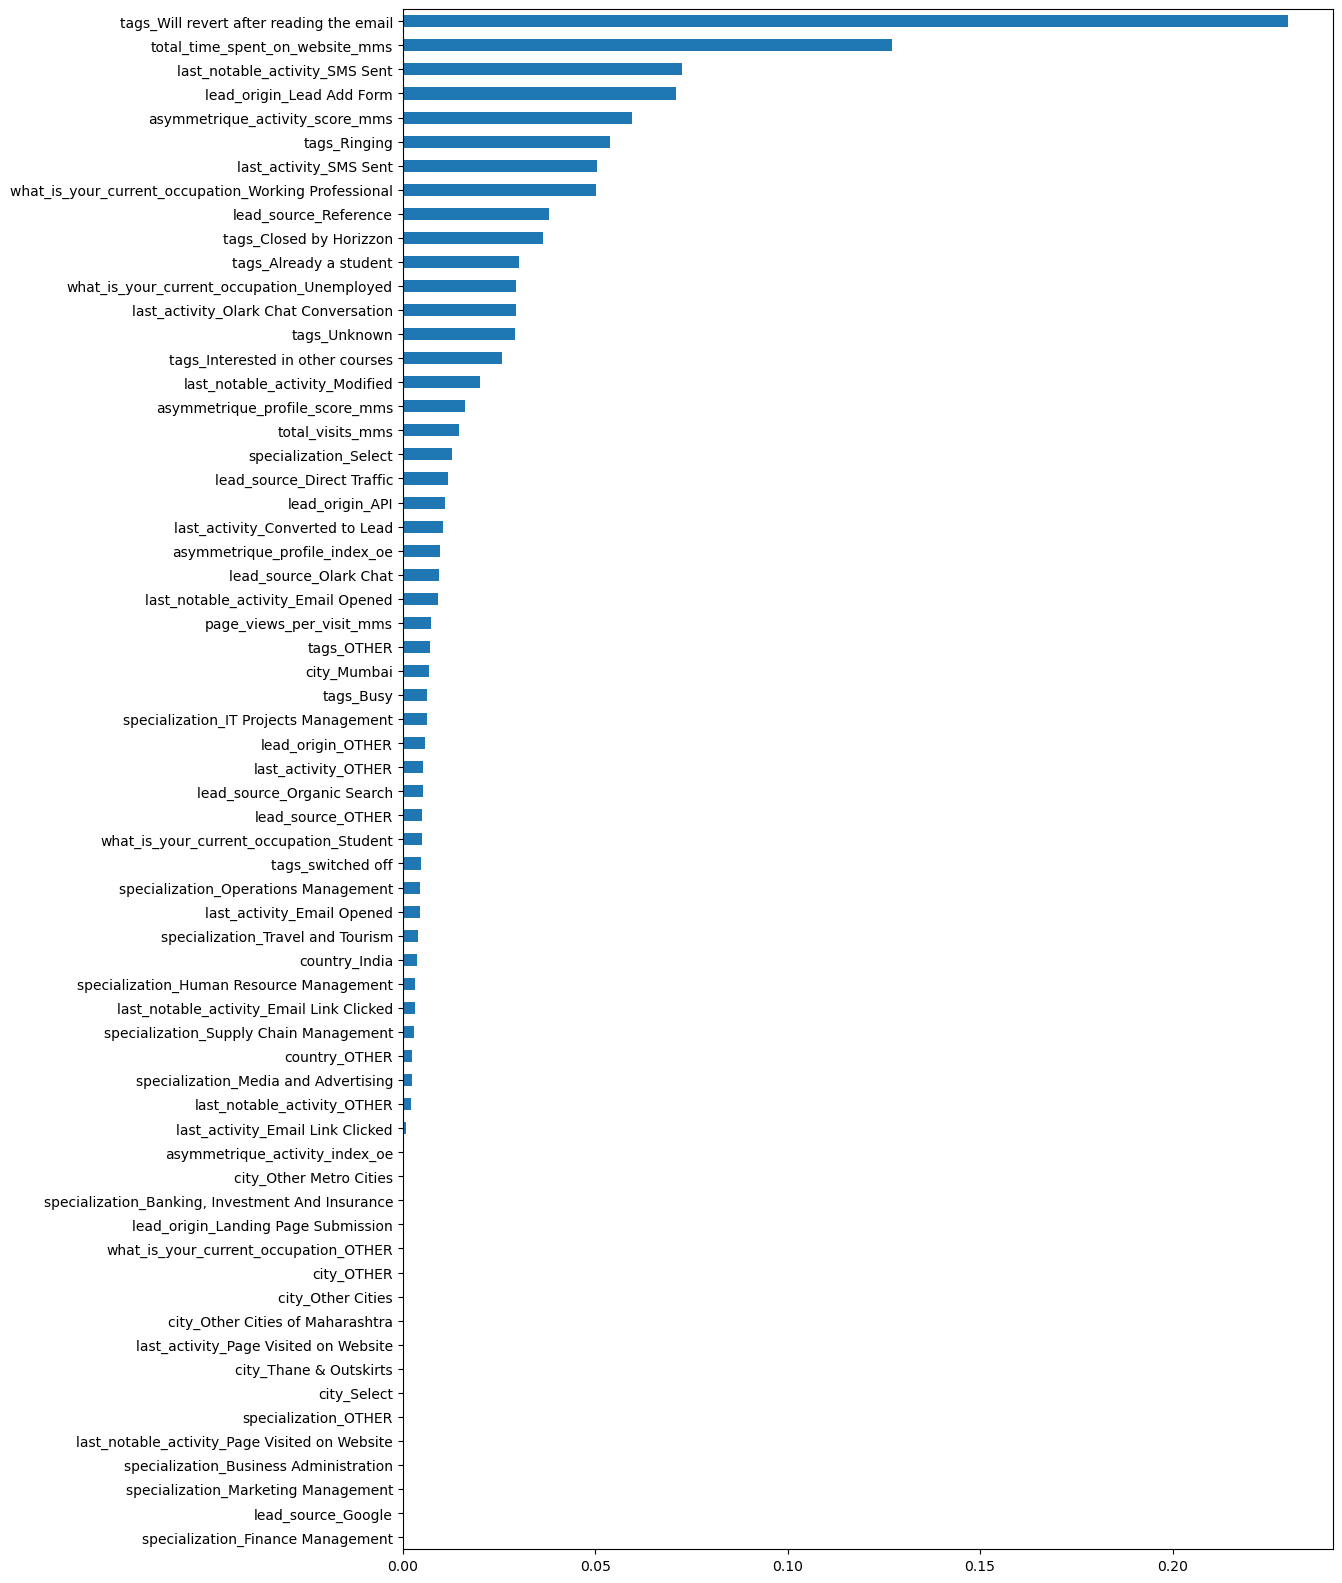

In [31]:
mutual_selector = mutual_info_classif(x,y)

rank_mi = ranking_mi(mutual_selector, modo = 'grafico')
plt.show();

#### Seleccionar las variables que pasan

##### Definir la posición de la última variable que va a entrar

In [33]:
posicion_variable_limite = 16

##### Extraer los nombres de las que entran

In [34]:
entran_mi = ranking_mi(mutual_selector).iloc[0:posicion_variable_limite].variable
entran_mi

42             tags_Will revert after reading the email
60                      total_time_spent_on_website_mms
56                       last_notable_activity_SMS Sent
2                             lead_origin_Lead Add Form
62                      asymmetrique_activity_score_mms
40                                         tags_Ringing
16                               last_activity_SMS Sent
34    what_is_your_current_occupation_Working Profes...
9                                 lead_source_Reference
37                              tags_Closed by Horizzon
35                               tags_Already a student
33           what_is_your_current_occupation_Unemployed
14                last_activity_Olark Chat Conversation
41                                         tags_Unknown
38                     tags_Interested in other courses
53                       last_notable_activity_Modified
Name: variable, dtype: object

##### Crear el dataframe con la selección

In [35]:
x_mi = x[entran_mi].copy()

### Recursive Feature Elimination

#### Instanciar

In [36]:
rfe = RFE(estimator = XGBClassifier( n_jobs = -1, eval_metric='auc'))

#### Entrenar

In [37]:
rfe.fit(x,y)

RFE(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=None, device=None,
                            early_stopping_rounds=None,
                            enable_categorical=False, eval_metric='auc',
                            feature_types=None, gamma=None, grow_policy=None,
                            importance_type=None, interaction_constraints=None,
                            learning_rate=None, max_bin=None,
                            max_cat_threshold=None, max_cat_to_onehot=None,
                            max_delta_step=None, max_depth=None,
                            max_leaves=None, min_child_weight=None, missing=nan,
                            monotone_constraints=None, multi_strategy=None,
                            n_estimators=None, n_jobs=-1,
                            num_parallel_tree=None, random_state=None, ...))

##### Extraer los nombres de las que entran

In [38]:
entran_rfe = x.columns[rfe.support_]
entran_rfe

Index(['lead_origin_Landing Page Submission', 'lead_origin_Lead Add Form',
       'last_activity_Converted to Lead', 'last_activity_Email Link Clicked',
       'last_activity_Email Opened', 'last_activity_OTHER',
       'last_activity_Olark Chat Conversation', 'last_activity_SMS Sent',
       'specialization_Finance Management',
       'specialization_Human Resource Management',
       'specialization_Operations Management',
       'specialization_Supply Chain Management',
       'what_is_your_current_occupation_Working Professional',
       'tags_Already a student', 'tags_Busy', 'tags_Closed by Horizzon',
       'tags_Interested in other courses', 'tags_OTHER', 'tags_Ringing',
       'tags_Unknown', 'tags_Will revert after reading the email',
       'tags_switched off', 'city_Other Cities',
       'last_notable_activity_Email Opened', 'last_notable_activity_Modified',
       'last_notable_activity_SMS Sent', 'asymmetrique_activity_index_oe',
       'asymmetrique_profile_index_oe', 'to

#### Crear el dataframe con la selección

In [39]:
x_rfe = x[entran_rfe].copy()

### Permutation Importance

#### Crear una función para mostrar el resultado

In [40]:
def ranking_per(predictoras,permutacion):
    ranking_per = pd.DataFrame({'variable': predictoras.columns, 'importancia_per': permutacion.importances_mean}).sort_values(by = 'importancia_per', ascending = False)
    ranking_per['ranking_per'] = np.arange(0,ranking_per.shape[0])
    return(ranking_per)

#### Instanciar y entrenar

In [41]:
import warnings
warnings.filterwarnings(action="ignore", message=r'.*Use subset.*of np.ndarray is not recommended')

xgb = XGBClassifier(n_jobs = -1, eval_metric='auc')

xgb.fit(x,y)

permutacion = permutation_importance(xgb, 
                                     x, y, 
                                     scoring = 'roc_auc',
                                     n_repeats=5, n_jobs = -1)

#### Revisar la salida

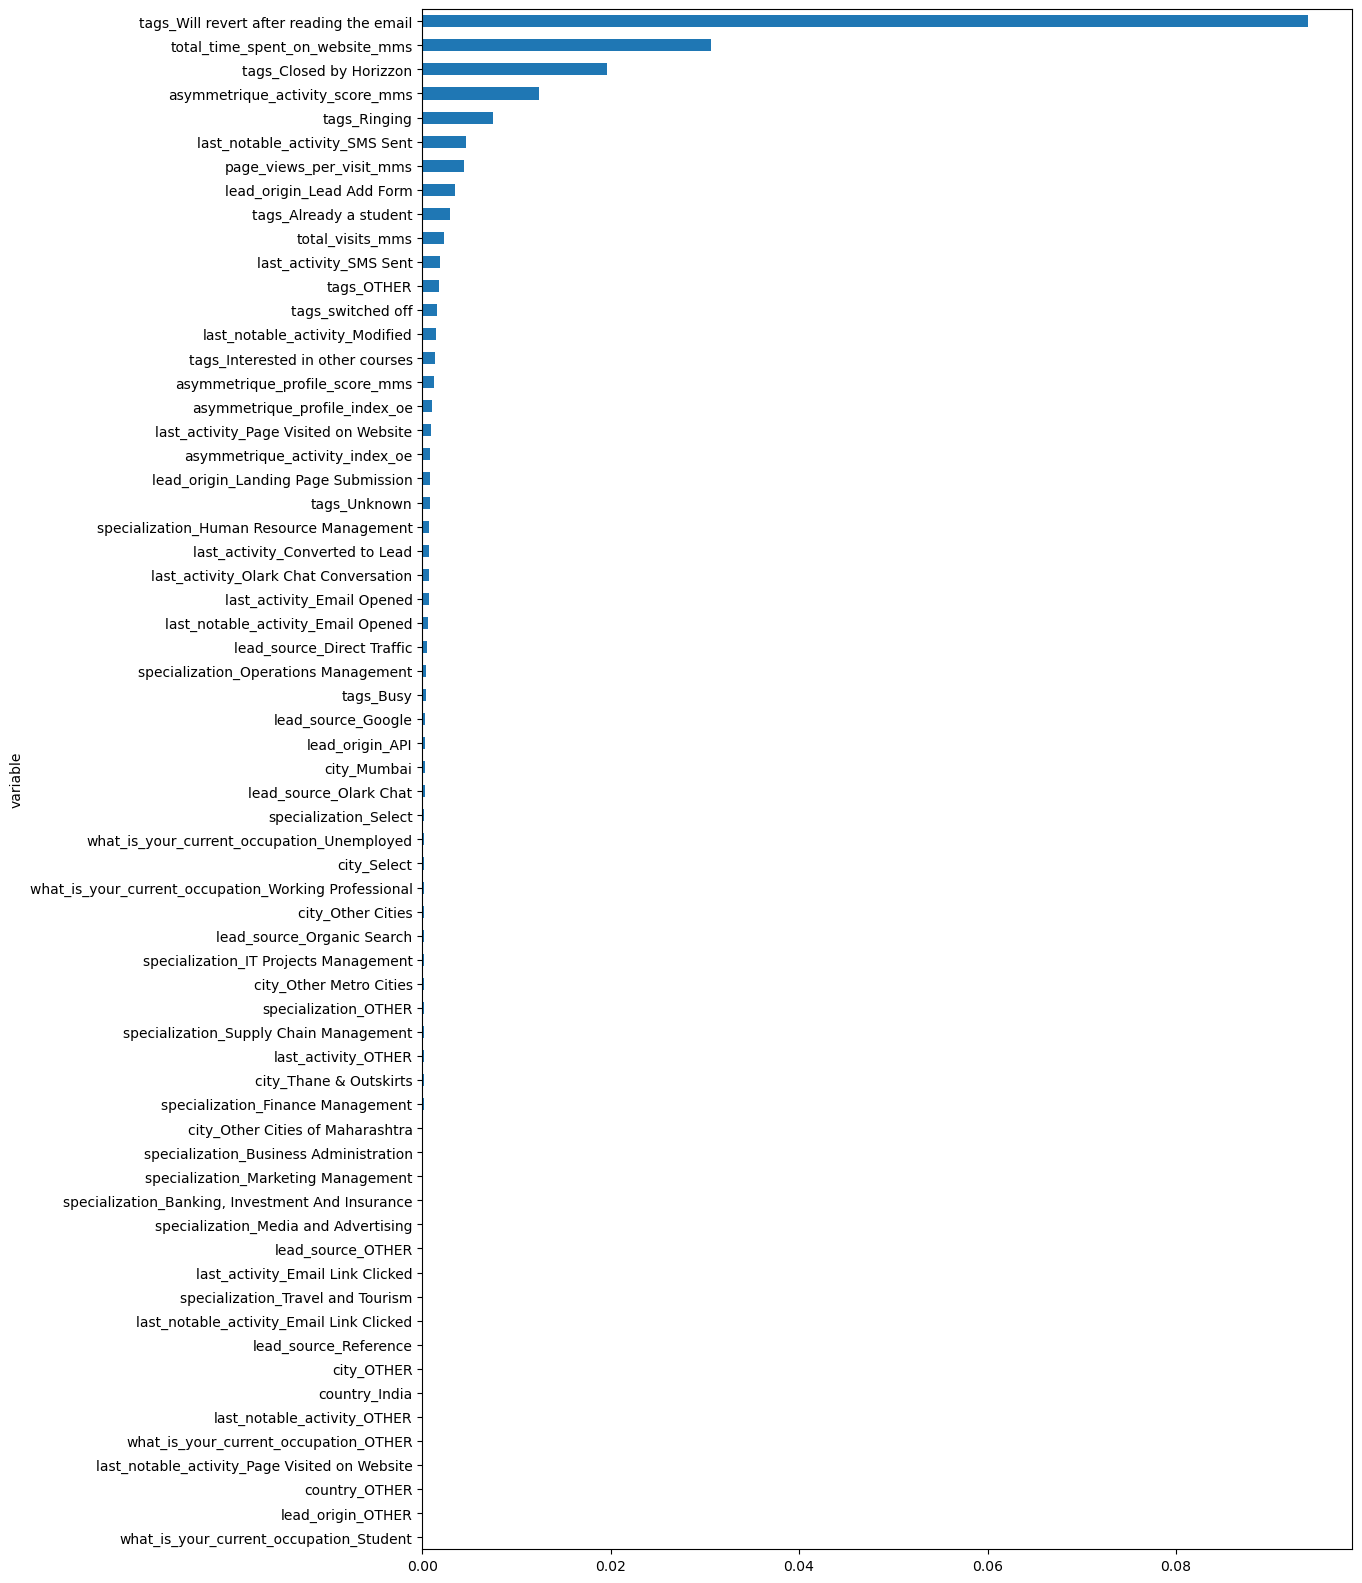

In [42]:
rank_per = ranking_per(x,permutacion)

rank_per.set_index('variable').importancia_per.sort_values().plot.barh(figsize = (12,20));
plt.show();

#### Seleccionar las variables que pasan

##### Definir la posición de la última variable que va a entrar

In [60]:
posicion_variable_limite = 12

##### Extraer los nombres de las que entran

In [61]:
entran_per = rank_per.iloc[0:posicion_variable_limite].variable
entran_per

42    tags_Will revert after reading the email
60             total_time_spent_on_website_mms
37                     tags_Closed by Horizzon
62             asymmetrique_activity_score_mms
40                                tags_Ringing
56              last_notable_activity_SMS Sent
61                    page_views_per_visit_mms
2                    lead_origin_Lead Add Form
35                      tags_Already a student
59                            total_visits_mms
16                      last_activity_SMS Sent
39                                  tags_OTHER
Name: variable, dtype: object

##### Crear el dataframe con la selección

In [62]:
x_per = x[entran_per].copy()

## SELECCIONAR EL MÉTODO FINAL

In [63]:
x_preseleccionado = x_per

## MÉTODOS NO SUPERVISADOS

### Correlación

#### Crear una función para mostrar el resultado

In [65]:
def correlaciones_fuertes(df, lim_inf = 0.3, lim_sup = 1,drop_dupli=True):
    #Calcula la matriz de correlación
    c = df.corr().abs()
    #Lo pasa todo a filas
    c= c.unstack()
    #Pasa el índice a columnas y le pone nombres
    c = pd.DataFrame(c).reset_index()
    c.columns = ['var1','var2','corr']
    #A dataframe, filtra limites y ordena en descendiente
    c = c.loc[(c['corr'] > lim_inf) &  (c['corr'] < lim_sup),:].sort_values(by = 'corr', ascending=False)
    #Desduplica las correlaciones (o no si drop_dupli es False)
    c = c if drop_dupli == False else c.drop_duplicates(subset = ['corr'])
    #Devuelve la salida
    return(c)

#### Calcular y revisar

##### Calcular

In [66]:
cor_finales = correlaciones_fuertes(x_preseleccionado)

##### Revisar agregado

In [67]:
cor_finales.var1.value_counts()

var1
total_time_spent_on_website_mms             2
last_notable_activity_SMS Sent              1
page_views_per_visit_mms                    1
tags_Closed by Horizzon                     1
tags_Will revert after reading the email    1
Name: count, dtype: int64

##### Revisar detalle

In [68]:
cor_finales.head(50)

,var1,var2,corr
70,last_notable_activity_SMS Sent,last_activity_SMS Sent,0.854396
81,page_views_per_visit_mms,total_visits_mms,0.686075
31,tags_Closed by Horizzon,lead_origin_Lead Add Form,0.343023
18,total_time_spent_on_website_mms,page_views_per_visit_mms,0.342064
21,total_time_spent_on_website_mms,total_visits_mms,0.328501
5,tags_Will revert after reading the email,last_notable_activity_SMS Sent,0.305829


#### Filtrar variables

Meter en una lista las que queramos descartar por alta correlacion y eliminarlas.

In [69]:
a_eliminar_corr = ['last_activity_SMS Sent']

In [70]:
x_preseleccionado.drop(columns = a_eliminar_corr, inplace = True)

In [71]:
x_preseleccionado.columns.to_list()

['tags_Will revert after reading the email',
 'total_time_spent_on_website_mms',
 'tags_Closed by Horizzon',
 'asymmetrique_activity_score_mms',
 'tags_Ringing',
 'last_notable_activity_SMS Sent',
 'page_views_per_visit_mms',
 'lead_origin_Lead Add Form',
 'tags_Already a student',
 'total_visits_mms',
 'tags_OTHER']

## GUARDAR DATASETS TRAS PRESELECCION DE VARIABLES

In [72]:
#Definir los nombres de los archivos
nombre_x_preseleccionado = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'x_preseleccionado.pickle'
nombre_y_preseleccionado = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'y_preseleccionado.pickle'

In [73]:
#Guardar los archivos
x_preseleccionado.to_pickle(nombre_x_preseleccionado)

y_preseleccionado = y.copy()
y_preseleccionado.to_pickle(nombre_y_preseleccionado)

In [74]:
#Guardar los nombres de las variables finales
nombre_variables_finales = ruta_proyecto + '/05_Resultados/' + 'variables_finales.pickle'

x_preseleccionado.iloc[0].to_pickle(nombre_variables_finales)